# Naive Bayes para Ejercicio Actual (ejer_act)

Curso: Minería de Datos en la Practica (UNAM)

Autor: Thanos Drossos

Este notebook implementa un clasificador Naive Bayes para predecir si una persona hace ejercicio actualmente (ejer_act) utilizando el conjunto de datos de salud. El análisis progresa desde la identificación de factores individuales hasta la puntuación general de pacientes, traduciendo datos de salud en conocimientos accionables.

## Importar bibliotecas y cargar datos

Cargaremos los datos, analizaremos las características básicas y prepararemos el conjunto de datos para el análisis de Naive Bayes.

Tamaño del dataset: 1076 filas, 500 columnas

Columnas en el dataset:
['ï»¿folio', 'id_dep', 'colonia', 'ciudad', 'id_estado', 'cp', 'nac_dia', 'nac_mes', 'nac_anio', 'id_puesto', 'id_sexo', 'id_edociv', 'id_gestud', 'num_fam', 'id_encuest', 'Apuesto', 'Aestado', 'Aedad', 'AAedad', 'dich_obes', 'edad_obes', 'dich_diab', 'edad_diab', 'dich_pre', 'edad_pre', 'dich_hiper', 'edad_hiper', 'dich_cardi', 'edad_cardi', 'dich_reti', 'edad_reti', 'dich_renal', 'edad_renal', 'dich_coles', 'edad_coles', 'dich_trigl', 'edad_trigl', 'dich_cmama', 'edad_cmama', 'dich_cpros', 'edad_cpros', 'dich_colon', 'edad_colon', 'dich_cotro', 'edad_cotro', 'dich_pulmo', 'edad_pulmo', 'dich_neuro', 'edad_neuro', 'dich_asma', 'edad_asma', 'nr_dich1', 'nr_dich2', 'salud_act', 'salud1', 'salud5', 'salud10', 'salud20', 'salud30', 'estres_act', 'estres1', 'estres5', 'estres10', 'estres20', 'estres30', 'condi_act', 'condi1', 'condi5', 'condi10', 'condi20', 'condi30', 'peso_act', 'peso1', 'peso5', 'peso10', 'peso20', 'pe

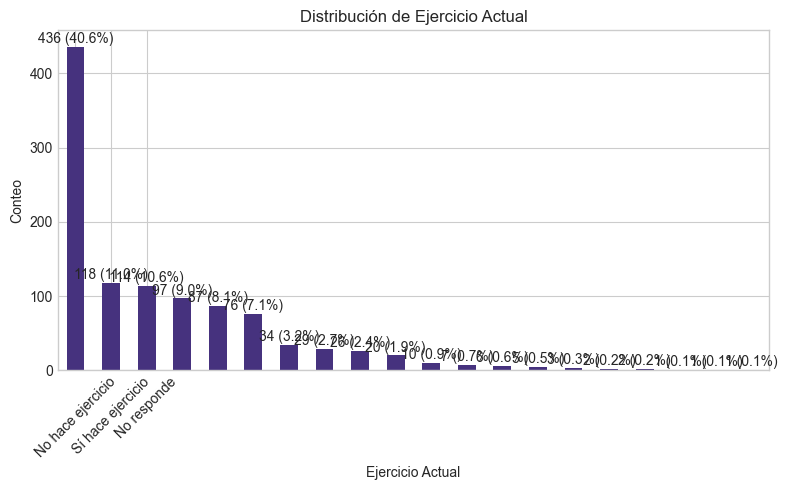

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configurar visualización
plt.style.use('seaborn-v0_8-whitegrid')  # Usando un estilo seaborn válido
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar el conjunto de datos
file_path = 'CSV 14UNI1_CAQ.csv'
df = pd.read_csv(file_path, encoding='latin1')

# Mostrar información básica
print(f"Tamaño del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nColumnas en el dataset:")
print(df.columns.tolist())

# Mostrar la distribución de la variable objetivo ejer_act
ejercicio_counts = df['ejer_act'].value_counts()
print("\nDistribución de ejercicio actual (ejer_act):")
print(ejercicio_counts)

# Valores únicos y su significado
# 0: No hace ejercicio
# 1: Sí hace ejercicio
# 2: No responde

# Visualizar la distribución
plt.figure(figsize=(8, 5))
ax = ejercicio_counts.plot(kind='bar')
plt.title('Distribución de Ejercicio Actual')
plt.xlabel('Ejercicio Actual')
plt.ylabel('Conteo')
plt.xticks(ticks=[0, 1, 2], labels=['No hace ejercicio', 'Sí hace ejercicio', 'No responde'], rotation=45)
for i, count in enumerate(ejercicio_counts):
    ax.text(i, count + 5, f'{count} ({count/sum(ejercicio_counts):.1%})', ha='center')
plt.tight_layout()
plt.show()

## Preparación de los datos

Prepararemos los datos para su análisis, limpiando valores nulos y seleccionando las características relevantes para nuestro modelo.

In [2]:
# Filtrar registros con respuesta válida (0 o 1) para ejer_act
df_clean = df[df['ejer_act'].isin([0, 1])].copy()
print(f"Registros válidos después de filtrar: {df_clean.shape[0]}")

# Verificar tipos de datos
print("\nTipos de datos:")
print(df_clean.dtypes.sort_values())

# Verificar valores nulos
missing_values = df_clean.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
print("\nColumnas con valores nulos:")
print(missing_values if len(missing_values) > 0 else "No hay valores nulos")

# Selección de variables potencialmente predictivas
# Excluimos ID, códigos, nombres y variables que no tienen relación lógica con ejercicio
variables_excluidas = [
    'folio', 'id_dep', 'colonia', 'ciudad', 'id_estado', 'cp',
    'nac_dia', 'nac_mes', 'nac_anio', 'id_puesto', 'id_encuest',
    'Apuesto', 'Aestado', 'tom_muest', 'id_fleb', 'id_med', 'id_medp',
    'id_medt', 'dia', 'mes', 'anio', 'leje_otroe', 'mcam_otroe', 'otro_act_e',
    'otro1_es', 'otro5_es', 'otro10_es', 'otro20_es', 'otro30_es',
    # También excluimos la variable objetivo y sus variantes
    'ejer_act', 'nr_ejer_ac', 'ejer', 'ejerint', 'nr_ejerc_ac', 'pesas_act', 'aero_act', 'camin_act', 'corre_Act', 'atle_act', 'dcont_act',
    'beis_Act', 'fut_act', 'basq_act', 'bail_act', 'bici_act', 'natac_act', 'raq_act', 'otro_act',
    'otro_act_e', 'ning_act', 'nqr_act', 'nr_ejer1', 'ejer1', 'pesas1', 'aero1', 'camin1', 'corre1',
    'atle1', 'dcont1', 'beis1', 'fut1', 'basq1', 'bail1', 'bici1', 'natac1', 'raq1', 'otro1',
    'otro1_es', 'ning1', 'nqr1', 'nr_ejer5', 'ejer5', 'pesas5', 'aero5', 'camin5', 'corre5', 'atle5',
    'dcont5', 'beis5', 'fut5', 'basq5', 'bail5', 'bici5', 'natac5', 'raq5', 'otro5', 'otro5_es',
    'ning5', 'nqr5', 'nr_ejer10', 'ejer10', 'pesas10', 'aero10', 'camin10', 'corre10', 'atle10',
    'dcont10', 'beis10', 'fut10', 'basq10', 'bail10', 'bici10', 'natac10', 'raq10', 'otro10',
    'otro10_es', 'ning10', 'nqr10', 'nr_ejer20', 'ejer20', 'pesas20', 'aero20', 'camin20', 'corre20',
    'atle20', 'dcont20', 'beis20', 'fut20', 'basq20', 'bail20', 'bici20', 'natac20', 'raq20', 'otro20',
    'otro20_es', 'ning20', 'nqr20', 'nr_ejer30', 'ejer30', 'pesas30', 'aero30', 'camin30', 'corre30',
    'atle30', 'dcont30', 'beis30', 'fut30', 'basq30', 'bail30', 'bici30', 'natac30', 'raq30', 'otro30',
    'otro30_es', 'ning30', 'nqr30', 'leje_priv', 'leje_pub', 'leje_gym', 'leje_alber', 'leje_parq',
    'leje_calle', 'leje_canch', 'leje_casa', 'leje_otro', 'leje_otroe', 'nr_leje', 'mcam_gusta',
    'mcam_rmed', 'mcam_bara', 'mcam_prac', 'mcam_salp', 'mcam_otro', 'mcam_otroe', 'nr_mcam',
    'ejer', 'ejerint', 'dis_dianr', 'dis_dia', 'dis1_dianr', 'dis1_dia', 'dis5_dianr', 'dis5_dia',
    'dis10_dian', 'dis10_dia', 'dis20_dian', 'dis20_dia', 'dis30_dian', 'dis30_dia', 'pesas_act', 'aero_act', 
    'camin_act', 'corre_act', 'atle_act', 'dcont_act',
    'beis_act', 'fut_act', 'basq_act', 'bail_act', 'bici_act', 'natac_act',
    'raq_act', 'otro_act', 'ning_act', 'nqr_act'
]

# Define exercise-related variables to exclude from analysis
exercise_variables = [

]

# Seleccionar variables potencialmente predictivas
variables_predictoras = [col for col in df_clean.columns if col not in variables_excluidas]
print(f"\nNúmero de variables predictoras seleccionadas: {len(variables_predictoras)}")
print(f"Primeras 10 variables: {variables_predictoras[:10]}")

Registros válidos después de filtrar: 533

Tipos de datos:
ï»¿folio       int64
peso_tpo       int64
nr_peso        int64
peso30         int64
peso20         int64
               ...  
otro5_es      object
otro_act_e    object
otro10_es     object
otro30_es     object
Apuesto       object
Length: 500, dtype: object

Columnas con valores nulos:
hij6_sobr     533
hij5_diab     533
her10_diab    533
tio17_diab    533
leje_otroe    533
             ... 
num_tio         1
ejer1           1
num_her         1
bduerme         1
id_sobrsoc      1
Length: 399, dtype: int64

Número de variables predictoras seleccionadas: 333
Primeras 10 variables: ['ï»¿folio', 'id_sexo', 'id_edociv', 'id_gestud', 'num_fam', 'Aedad', 'AAedad', 'dich_obes', 'edad_obes', 'dich_diab']


## Función de cálculo de estadísticas para Naive Bayes

Implementaremos funciones para calcular las estadísticas necesarias para el clasificador Naive Bayes.

In [3]:
# Función para calcular estadísticas Naive Bayes para un par característica-valor
def calculate_stats(feature, value, description, subcategory, is_threshold=False):
    if is_threshold:
        condition = df_clean[feature] >= value
        value_display = f"≥ {value}"
        response = value_display
    else:
        condition = df_clean[feature] == value
        value_display = value
        response = str(value)
    
    # Contar instancias
    N_X = condition.sum()
    N_CX = ((df_clean['ejer_act'] == 1) & condition).sum()
    N_not_CX = N_X - N_CX
    
    # Calcular probabilidades
    P_C_given_X = N_CX / N_X if N_X > 0 else 0
    prior_probability = df_clean['ejer_act'].mean()
    
    # Calcular Epsilon
    if N_X > 0 and prior_probability < 1 and prior_probability > 0:
        epsilon = (N_X * (P_C_given_X - prior_probability)) / (N_X * prior_probability * (1 - prior_probability))**0.5
    else:
        epsilon = 0
    
    # Calcular Score
    positive_instances = df_clean['ejer_act'].sum()
    negative_instances = len(df_clean) - positive_instances
    P_X_given_C = N_CX / positive_instances if positive_instances > 0 else 0
    P_X_given_not_C = N_not_CX / negative_instances if negative_instances > 0 else 0
    
    if P_X_given_not_C > 0 and P_X_given_C > 0:
        score_X = math.log(P_X_given_C / P_X_given_not_C)
    else:
        score_X = 0
    
    s_r = math.log(prior_probability / (1 - prior_probability)) if prior_probability < 1 and prior_probability > 0 else 0
    score = score_X + s_r
    
    return {
        'Subcategoría': subcategory,
        'Descripción': description,
        'Respuesta': response,
        'N(CX)': N_CX,
        'N(X)': N_X,
        'P(C|X)': round(P_C_given_X, 2),
        'P(C)': round(prior_probability, 2),
        'Epsilon': round(epsilon, 2),
        'Score': round(score, 2),
        'N(C)': positive_instances,
        'N': len(df_clean),
        'N(-C)': negative_instances,
        'N(-CX)': N_not_CX,
        'Feature': feature,
        'Value': value,
        'Is_Threshold': is_threshold
    }

## Análisis uniperspectivo: factores individuales

Analizaremos cada característica individualmente para identificar los factores más influyentes en la predicción de ejercicio actual.

In [4]:
# Diccionario para categorizar variables
categories = {
    'Demografía': ['id_sexo', 'id_edociv', 'id_gestud', 'num_fam', 'Aedad', 'AAedad', 'edad_obes'],
    'Salud': ['dich_obes', 'dich_diab', 'edad_diab', 'dich_pre', 'edad_pre', 'dich_hiper', 
              'edad_hiper', 'dich_cardi', 'edad_cardi', 'dich_reti', 'edad_reti', 'dich_renal', 
              'edad_renal', 'dich_coles', 'edad_coles', 'dich_trigl', 'edad_trigl', 'dich_cmama',
              'edad_cmama', 'dich_cpros', 'edad_cpros', 'dich_colon', 'edad_colon', 'dich_cotro',
              'edad_cotro', 'dich_pulmo', 'edad_pulmo', 'dich_neuro', 'edad_neuro', 'dich_asma', 
              'edad_asma', 'nr_dich1', 'nr_dich2'],
    'Percepción': ['salud_act', 'salud1', 'salud5', 'salud10', 'salud20', 'salud30',
                   'estres_act', 'estres1', 'estres5', 'estres10', 'estres20', 'estres30',
                   'condi_act', 'condi1', 'condi5', 'condi10', 'condi20', 'condi30'],
    'Peso': ['peso_act', 'peso1', 'peso5', 'peso10', 'peso20', 'peso30', 'aes_peso', 'nr_peso',
             'peso_tpo', 'estatura', 'peso_acc', 'peso_ehoy', 'peso_edes', 'AIMC'],
    'Familia': ['num_her', 'her1_edad', 'her1_sobr', 'her1_diab', 'her1_vivo',
                'num_tio', 'tio1_edad', 'tio1_sobr', 'tio1_diab', 'tio1_vivo',
                'num_hij', 'hij1_edad', 'hij1_sobr', 'hij1_diab', 'hij1_peso',
                'mad_vivo', 'pad_vivo', 'mad_edad', 'pad_edad', 'mad_sobr', 'pad_sobr',
                'mad_diab', 'pad_diab'],
    'Abuelos': ['mlito_vivo', 'mlita_vivo', 'plito_vivo', 'plita_vivo',
               'mlito_edad', 'mlita_edad', 'plito_edad', 'plita_edad',
               'mlito_sobr', 'mlita_sobr', 'plito_sobr', 'plita_sobr',
               'mlito_diab', 'mlita_diab', 'plito_diab', 'plita_diab'],
    'Amigos': ['num_ami', 'ami1_edad', 'ami1_sobr', 'ami1_diab'],
    'Antropometría': ['talla', 'peso', 'cintura', 'brazo', 'temp', 'diastolica', 'sistolica'],
    'Hábitos': ['duerme', 'nr_duerme', 'bduerme', 'nr_bduerme', 'alc', 'nr_alc', 'tpoalc', 'nr_tpoalc',
               'fuma', 'tpofuma', 'nr_tpofuma', 'fuma_act', 'dejarfumar', 'cigarros'],
    'Ejercicio previo': ['ejer1', 'nr_ejer1', 'ejer5', 'nr_ejer5', 'ejer10', 'nr_ejer10',
                         'ejer20', 'nr_ejer20', 'ejer30', 'nr_ejer30'],
    'Motivación': ['mcam_gusta', 'mcam_rmed', 'mcam_bara', 'mcam_prac', 'mcam_salp', 'mcam_otro',
                   'nr_mcam'],
    'Análisis': ['glu', 'tgb', 'chol', 'hdld', 'uric', 'crs', 'ldlc_res', 'hba', 'insulina']
}

# Crear diccionario inverso para categorías
feature_to_category = {}
for category, features in categories.items():
    for feature in features:
        feature_to_category[feature] = category

# Inicializar lista de resultados
results = []

# Procesar cada característica
for feature in variables_predictoras:
    if feature not in feature_to_category:
        continue  # Saltamos variables sin categoría asignada
        
    category = feature_to_category[feature]
    
    # Analizar cada valor único para la característica
    unique_values = sorted(df_clean[feature].dropna().unique())
    
    for value in unique_values:
        description = f"{feature} = {value}"
        results.append(calculate_stats(feature, value, description, category))
    
    # Para algunas variables numéricas, analizar valores de umbral
    if feature in ['edad_diab', 'edad_hiper', 'edad_cardi', 'peso_act', 'num_fam', 'peso', 'cintura',
                  'sistolica', 'diastolica', 'AIMC', 'glu', 'chol', 'hdld', 'tgb']:
        percentiles = [25, 50, 75]  # Analizar percentiles como umbrales
        for p in percentiles:
            threshold = df_clean[feature].dropna().quantile(p/100)
            description = f"{feature} >= {threshold}"
            results.append(calculate_stats(feature, threshold, description, category, is_threshold=True))

# Crear DataFrame con resultados
results_df = pd.DataFrame(results)

# Ordenar por valor absoluto de epsilon para encontrar los factores más significativos
results_df['Abs_Epsilon'] = results_df['Epsilon'].abs()
results_df = results_df.sort_values(by='Abs_Epsilon', ascending=False).drop(columns=['Abs_Epsilon'])

# Mostrar los 20 factores más importantes
top_drivers = results_df.head(20)
print("Top 20 factores más influyentes para predecir ejercicio actual:")
display(top_drivers[['Subcategoría', 'Descripción', 'P(C|X)', 'P(C)', 'Epsilon', 'Score', 'N(X)']])

Top 20 factores más influyentes para predecir ejercicio actual:


,Subcategoría,Descripción,P(C|X),P(C),Epsilon,Score,N(X)
2786,Análisis,tgb = 155.0,1.00,0.18,3.67,-1.50,3
1939,Antropometría,sistolica = 150,1.00,0.18,3.67,-1.50,3
943,Familia,tio1_edad = 92.0,1.00,0.18,3.67,-1.50,3
2452,Hábitos,alc = 14.0,1.00,0.18,3.67,-1.50,3
539,Percepción,condi_act = 4,0.32,0.18,3.31,-0.78,92
2449,Hábitos,alc = 10.0,0.67,0.18,3.08,0.69,6
1726,Antropometría,peso = 108.0,1.00,0.18,3.00,-1.50,2
1150,Familia,mad_edad = 91.0,1.00,0.18,3.00,-1.50,2
3079,Análisis,chol = 268.0,1.00,0.18,3.00,-1.50,2
149,Demografía,edad_obes = 60.0,1.00,0.18,3.00,-1.50,2


## Visualización de factores importantes

Visualizaremos los factores más importantes para comprender mejor su impacto en la predicción.

C:\Users\thano\AppData\Local\Temp\ipykernel_21036\2618474086.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Epsilon', y='Descripción', data=top15, palette='viridis')


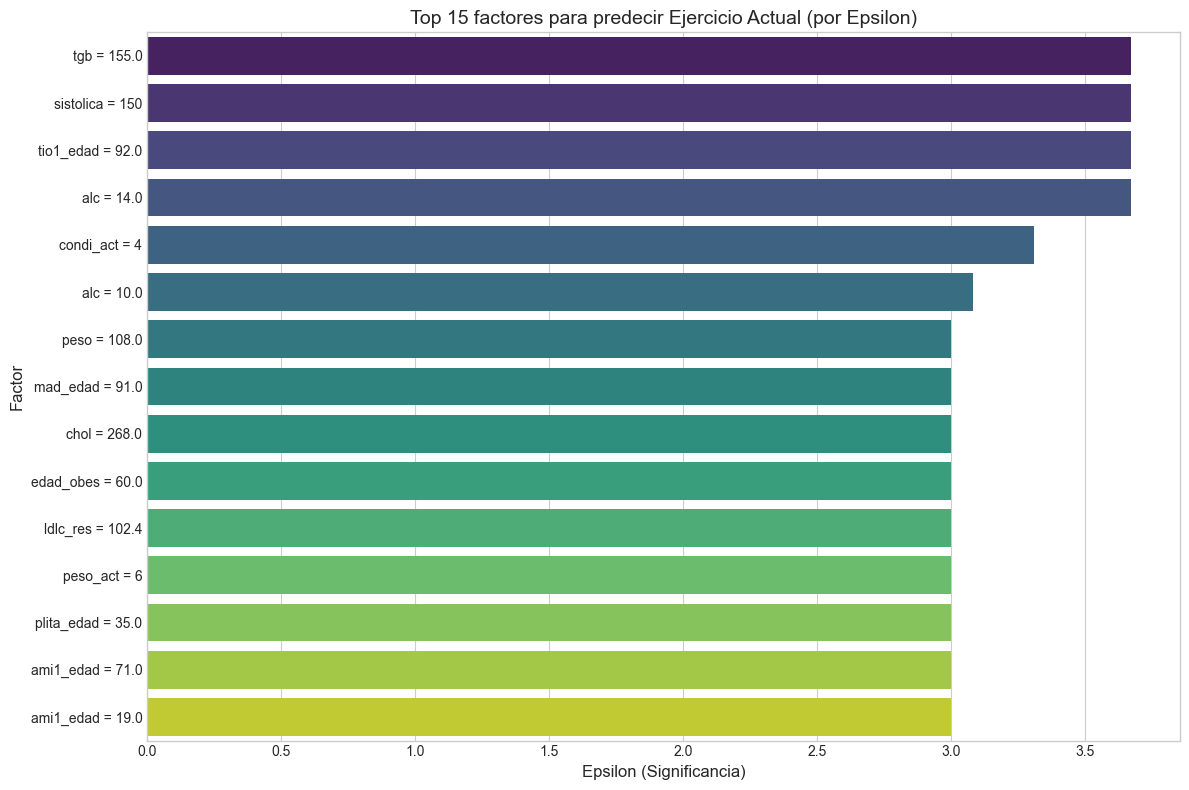

C:\Users\thano\AppData\Local\Temp\ipykernel_21036\2618474086.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='P(C|X)', y='Descripción', data=top15, palette='viridis')


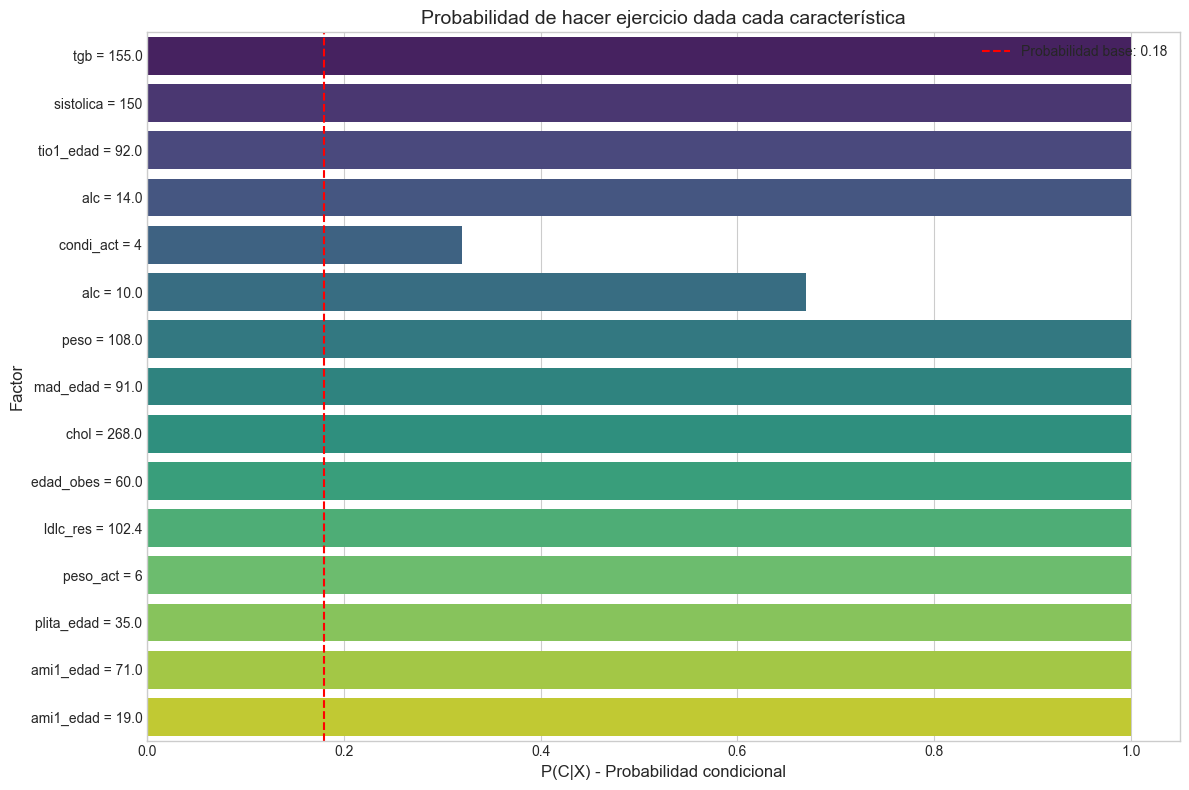

In [5]:
# Visualizar top 15 factores por epsilon
plt.figure(figsize=(12, 8))
top15 = results_df.head(15)
sns.barplot(x='Epsilon', y='Descripción', data=top15, palette='viridis')
plt.title('Top 15 factores para predecir Ejercicio Actual (por Epsilon)', fontsize=14)
plt.xlabel('Epsilon (Significancia)', fontsize=12)
plt.ylabel('Factor', fontsize=12)
plt.tight_layout()
plt.show()

# Visualizar probabilidad condicional P(C|X) para top factores
plt.figure(figsize=(12, 8))
sns.barplot(x='P(C|X)', y='Descripción', data=top15, palette='viridis')
plt.axvline(x=top15['P(C)'].iloc[0], color='red', linestyle='--', label=f'Probabilidad base: {top15["P(C)"].iloc[0]:.2f}')
plt.title('Probabilidad de hacer ejercicio dada cada característica', fontsize=14)
plt.xlabel('P(C|X) - Probabilidad condicional', fontsize=12)
plt.ylabel('Factor', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## Análisis por categoría

Analizaremos qué categorías de factores tienen mayor influencia en la predicción de ejercicio actual.

Importancia por categoría:


,Factores,Epsilon_Promedio,Max_Epsilon
Subcategoría,,,
Antropometría,359,0.787855,3.67
Análisis,1348,0.801120,3.67
Familia,455,0.794242,3.67
Hábitos,170,0.851765,3.67
Percepción,118,0.888390,3.31
Abuelos,288,0.855208,3.00
Amigos,71,0.867042,3.00
Demografía,149,0.740872,3.00
Peso,671,0.807675,3.00


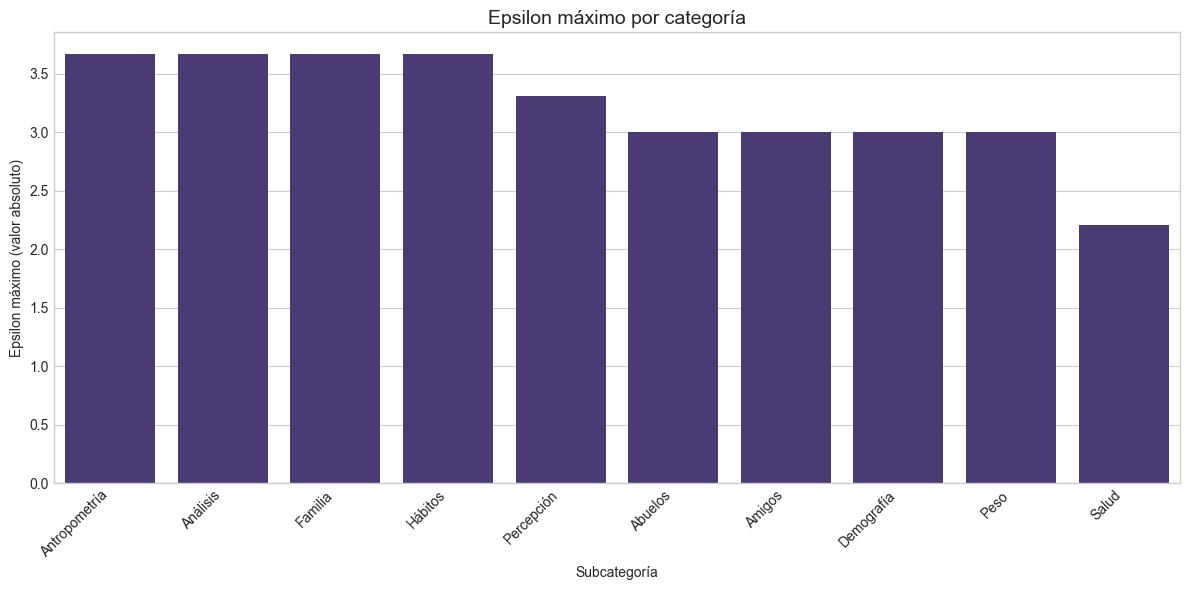

In [6]:
# Agrupar por categoría
category_results = results_df.groupby('Subcategoría').agg(
    Factores=('Descripción', 'count'),
    Epsilon_Promedio=('Epsilon', lambda x: abs(x).mean()),
    Max_Epsilon=('Epsilon', lambda x: abs(x).max())
).sort_values(by='Max_Epsilon', ascending=False)

print("Importancia por categoría:")
display(category_results)

# Visualizar epsilon máximo por categoría
plt.figure(figsize=(12, 6))
sns.barplot(x=category_results.index, y='Max_Epsilon', data=category_results)
plt.title('Epsilon máximo por categoría', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Epsilon máximo (valor absoluto)')
plt.tight_layout()
plt.show()

## Modelo predictivo con Naive Bayes

Ahora implementaremos un modelo predictivo utilizando los factores más importantes que hemos identificado.

In [7]:
def calculate_customer_scores(df, top_drivers):
    print("Calculando puntuaciones para todos los pacientes...")
    
    # Obtener probabilidad previa de hacer ejercicio
    prior_probability = df['ejer_act'].mean()
    prior_odds = prior_probability / (1 - prior_probability)
    log_prior = math.log(prior_odds) if prior_odds > 0 else 0
    
    # Inicializar array para puntuaciones
    customer_scores = np.ones(len(df)) * log_prior
    
    # Diccionario para almacenar razones de verosimilitud
    likelihood_ratios = {}
    
    # Seguimiento de características utilizadas
    used_features = set()
    selected_features = []
    
    # Usar los top drivers (características más predictivas)
    for _, row in top_drivers.iterrows():
        feature = row['Feature']
        value = row['Value']
        is_threshold = row['Is_Threshold']
        
        # Omitir si la característica ya se ha utilizado
        if feature in used_features:
            continue
            
        # Agregar característica al conjunto de utilizadas
        used_features.add(feature)
        
        # Registrar la característica seleccionada
        feature_desc = {
            'feature': feature,
            'value': value,
            'is_threshold': is_threshold
        }
        selected_features.append(feature_desc)
        
        # Crear condición
        if is_threshold:
            condition = df[feature] >= value
        else:
            condition = df[feature] == value
        
        # Contar pacientes que hacen y no hacen ejercicio
        positive_instances = df['ejer_act'].sum()
        negative_instances = len(df) - positive_instances
        
        # Calcular probabilidades condicionales con suavizado de Laplace
        count_with_C = ((df['ejer_act'] == 1) & condition).sum() + 1
        count_with_not_C = (condition & (df['ejer_act'] == 0)).sum() + 1
        
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calcular razón de log-verosimilitud
        log_ratio = math.log(P_X_given_C / P_X_given_not_C)
        
        # Aplicar a pacientes que coinciden
        customer_scores[condition] += log_ratio
        
        # Para pacientes que no coinciden, aplicar la verosimilitud complementaria
        comp_count_with_C = positive_instances - ((df['ejer_act'] == 1) & condition).sum() + 1
        comp_count_with_not_C = negative_instances - (condition & (df['ejer_act'] == 0)).sum() + 1
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C)
        
        customer_scores[~condition] += comp_log_ratio
    
    # Determinar el nombre correcto de la columna folio
    folio_column = 'folio' if 'folio' in df.columns else 'ï»¿folio'
    
    # Crear DataFrame con IDs y puntuaciones
    scores_df = pd.DataFrame({
        'Folio': df[folio_column],
        'Score': customer_scores,
        'Probability': 1 / (1 + np.exp(-customer_scores)),  # Convertir log-odds a probabilidad
        'Actual': df['ejer_act']
    })
    
    # Ordenar por puntuación en orden descendente
    scores_df = scores_df.sort_values(by='Score', ascending=False)
    
    # Calcular lift para los grupos de N principales
    for n in [10, 20, 50, 100]:
        if len(scores_df) >= n:
            top_n = scores_df.head(n)
            lift = (top_n['Actual'].mean() / prior_probability)
            print(f"Lift para los {n} principales pacientes: {lift:.2f}x")
    
    return scores_df, used_features, selected_features

# Calcular puntuaciones usando los 20 principales drivers
top_drivers_for_scoring = results_df.head(20)

# Calcular puntuaciones y obtener características seleccionadas
patient_scores, used_features, selected_features = calculate_customer_scores(
    df_clean, top_drivers_for_scoring
)

# Mostrar características seleccionadas
print("\n=== CARACTERÍSTICAS SELECCIONADAS PARA EL MODELO FINAL ===")
for i, feature in enumerate(selected_features, 1):
    if feature['is_threshold']:
        feature_desc = f"{feature['feature']} >= {feature['value']}"
    else:
        feature_desc = f"{feature['feature']} = {feature['value']}"
    
    print(f"{i}. {feature_desc}")

print(f"\nNúmero total de características únicas utilizadas: {len(used_features)}")
print("Lista de características:", ", ".join(sorted(used_features)))

# Mostrar los 20 pacientes con mayor probabilidad de hacer ejercicio
print("\nTop 20 pacientes con mayor probabilidad de hacer ejercicio:")
top_patients = patient_scores.head(20)
display(top_patients[['Folio', 'Score', 'Probability', 'Actual']])

# Calcular métricas de rendimiento
total_positive = df_clean['ejer_act'].sum()
print(f"\nTotal de pacientes que hacen ejercicio: {total_positive}")
print(f"Probabilidad base: {(total_positive / len(df_clean)) * 100:.2f}%")

# Calcular precisión en diferentes umbrales
for k in [10, 20, 50, 100]:
    if len(patient_scores) >= k:
        precision = patient_scores.head(k)['Actual'].sum() / k
        recall = patient_scores.head(k)['Actual'].sum() / total_positive
        print(f"Precisión@{k}: {precision*100:.2f}%, Recall@{k}: {recall*100:.2f}%")

Calculando puntuaciones para todos los pacientes...
Lift para los 10 principales pacientes: 5.49x
Lift para los 20 principales pacientes: 5.49x
Lift para los 50 principales pacientes: 3.63x
Lift para los 100 principales pacientes: 2.53x

=== CARACTERÍSTICAS SELECCIONADAS PARA EL MODELO FINAL ===
1. tgb = 155.0
2. sistolica = 150
3. tio1_edad = 92.0
4. alc = 14.0
5. condi_act = 4
6. peso = 108.0
7. mad_edad = 91.0
8. chol = 268.0
9. edad_obes = 60.0
10. ldlc_res = 102.4
11. peso_act = 6
12. plita_edad = 35.0
13. ami1_edad = 71.0
14. tpoalc = 18.0

Número total de características únicas utilizadas: 14
Lista de características: alc, ami1_edad, chol, condi_act, edad_obes, ldlc_res, mad_edad, peso, peso_act, plita_edad, sistolica, tgb, tio1_edad, tpoalc

Top 20 pacientes con mayor probabilidad de hacer ejercicio:


,Folio,Score,Probability,Actual
353,762,4.332647,0.987037,1.0
19,665,4.332647,0.987037,1.0
1045,521,3.698337,0.975834,1.0
513,14,3.002899,0.952705,1.0
443,703,1.718450,0.847929,1.0
497,1043,1.718450,0.847929,1.0
177,471,1.420297,0.805385,1.0
91,122,1.420297,0.805385,1.0
1027,342,0.785986,0.686969,1.0
971,317,0.785986,0.686969,1.0



Total de pacientes que hacen ejercicio: 97.0
Probabilidad base: 18.20%
Precisión@10: 100.00%, Recall@10: 10.31%
Precisión@20: 100.00%, Recall@20: 20.62%
Precisión@50: 66.00%, Recall@50: 34.02%
Precisión@100: 46.00%, Recall@100: 47.42%


## Evaluación del modelo y visualización de resultados

Evaluaremos el rendimiento del modelo y visualizaremos los resultados.

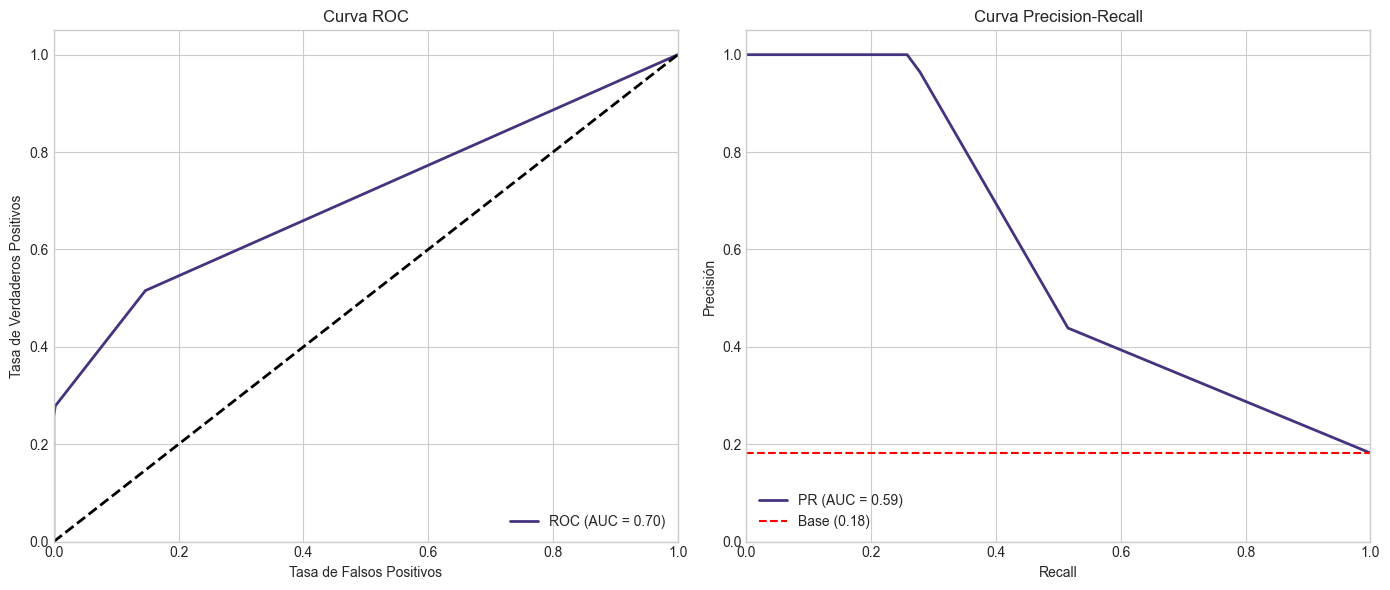

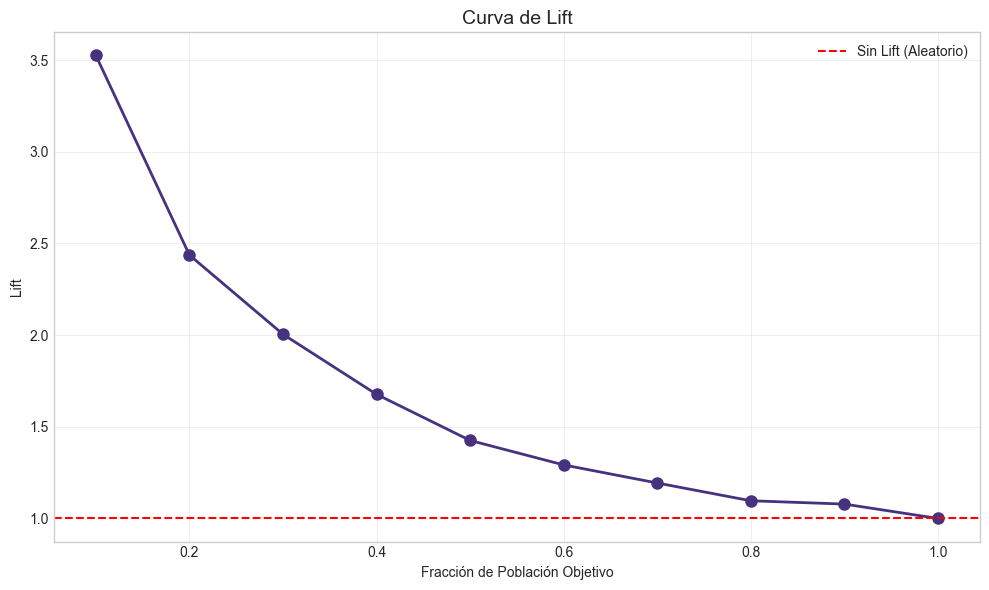

In [8]:
# Calcular curva ROC y AUC
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Calcular ROC
fpr, tpr, thresholds = roc_curve(patient_scores['Actual'], patient_scores['Probability'])
roc_auc = auc(fpr, tpr)

# Calcular Precision-Recall
precision, recall, _ = precision_recall_curve(patient_scores['Actual'], patient_scores['Probability'])
pr_auc = auc(recall, precision)

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Curva ROC
ax1.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos')
ax1.set_title('Curva ROC')
ax1.legend(loc="lower right")

# Curva Precision-Recall
ax2.plot(recall, precision, lw=2, label=f'PR (AUC = {pr_auc:.2f})')
base_line = len(patient_scores[patient_scores['Actual'] == 1]) / len(patient_scores)
ax2.axhline(y=base_line, color='r', linestyle='--', label=f'Base ({base_line:.2f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precisión')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

# Visualizar lift
percentiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
lifts = []

for p in percentiles:
    cutoff = int(len(patient_scores) * p)
    if cutoff > 0:
        top_p_percent = patient_scores.head(cutoff)
        lift = top_p_percent['Actual'].mean() / base_line
        lifts.append(lift)

plt.figure(figsize=(10, 6))
plt.plot(percentiles, lifts, 'o-', linewidth=2, markersize=8)
plt.axhline(y=1, color='r', linestyle='--', label='Sin Lift (Aleatorio)')
plt.title('Curva de Lift', fontsize=14)
plt.xlabel('Fracción de Población Objetivo')
plt.ylabel('Lift')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Análisis de necesidad y suficiencia

Analizaremos si los principales factores son necesarios, suficientes o ambos para predecir si una persona hace ejercicio.

Análisis Bayesiano de Necesidad y Suficiencia:


,Feature,Value,Coverage,Precision,Recall,Lift,Necessary,Sufficient,Interpretation
0,tgb,155.0,0.56%,100.00%,3.09%,5.49x,No,Sí,Suficiente pero no Necesaria
1,sistolica,150,0.56%,100.00%,3.09%,5.49x,No,Sí,Suficiente pero no Necesaria
2,tio1_edad,92.0,0.56%,100.00%,3.09%,5.49x,No,Sí,Suficiente pero no Necesaria
3,alc,14.0,0.56%,100.00%,3.09%,5.49x,No,Sí,Suficiente pero no Necesaria
4,condi_act,4,17.26%,31.52%,29.90%,1.73x,No,No,Ni Necesaria ni Suficiente
5,alc,10.0,1.13%,66.67%,4.12%,3.66x,No,Sí,Suficiente pero no Necesaria
6,peso,108.0,0.38%,100.00%,2.06%,5.49x,No,Sí,Suficiente pero no Necesaria
7,mad_edad,91.0,0.38%,100.00%,2.06%,5.49x,No,Sí,Suficiente pero no Necesaria
8,chol,268.0,0.38%,100.00%,2.06%,5.49x,No,Sí,Suficiente pero no Necesaria
9,edad_obes,60.0,0.38%,100.00%,2.06%,5.49x,No,Sí,Suficiente pero no Necesaria


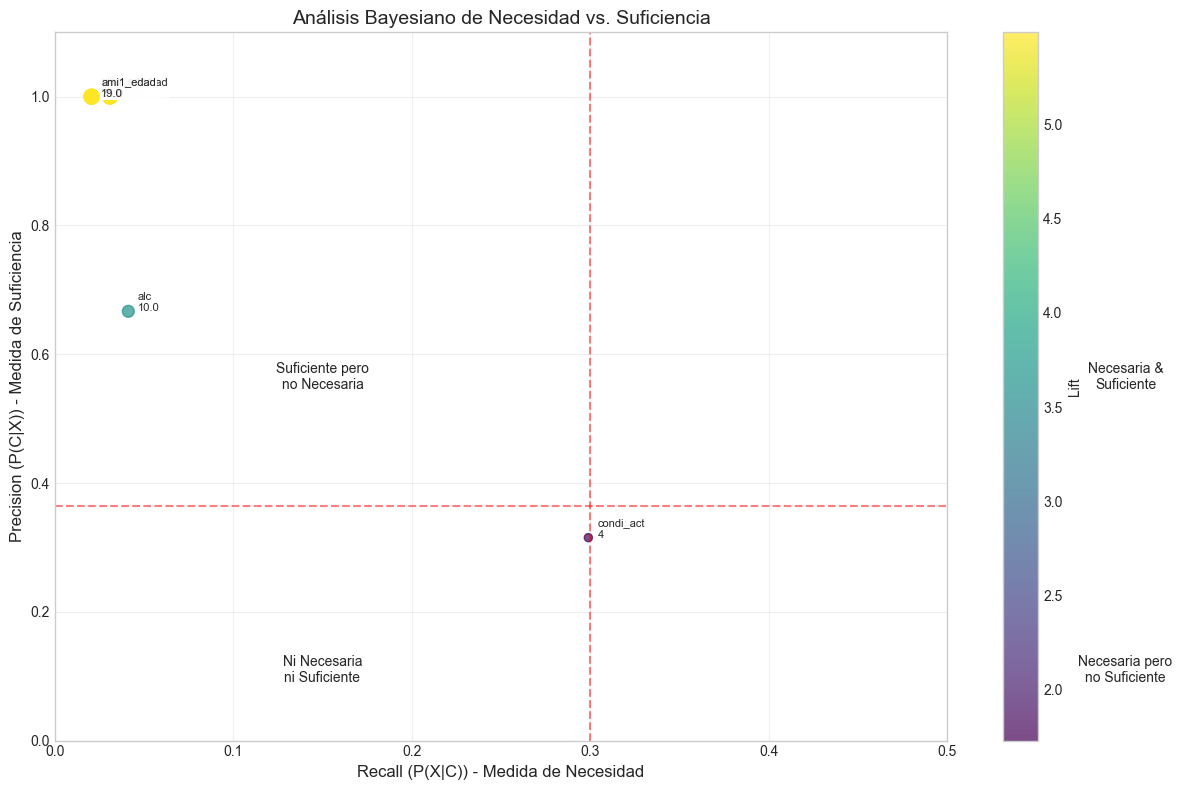

In [9]:
# Análisis mejorado de condiciones necesarias y suficientes
feature_analysis = []

# Extraer las principales características del análisis uniperspectivo
key_features = []
for _, row in top_drivers.head(15).iterrows():  # Usar las 15 principales
    key_features.append((row['Feature'], row['Value'], row['Is_Threshold']))

total_patients = len(df_clean)
total_exercisers = df_clean['ejer_act'].sum()
base_rate = total_exercisers / total_patients

for feature, value, is_threshold in key_features:
    # Crear condición
    if is_threshold:
        condition = (df_clean[feature] >= value)
        value_label = f">= {value}"
    else:
        condition = (df_clean[feature] == value)
        value_label = str(value)
        
    patients_with_feature = condition.sum()
    p_x = patients_with_feature / total_patients
    
    exercisers_with_feature = (condition & (df_clean['ejer_act'] == 1)).sum()
    p_x_given_c = exercisers_with_feature / total_exercisers if total_exercisers > 0 else 0
    p_c_given_x = exercisers_with_feature / patients_with_feature if patients_with_feature > 0 else 0
    
    # Calcular métricas
    lift = p_c_given_x / base_rate if base_rate > 0 else 0
    
    # Calcular cobertura y precisión
    coverage = p_x  # ¿Qué tan común es esta característica?
    precision = p_c_given_x  # ¿Qué probabilidad hay de que personas con esta característica hagan ejercicio?
    recall = p_x_given_c  # ¿Qué porcentaje de personas que hacen ejercicio tienen esta característica?
    
    # Determinar necesidad y suficiencia basada en métricas más apropiadas
    necessary = recall > 0.3  # La característica aparece en >30% de todos los casos positivos
    sufficient = precision > (2 * base_rate)  # La característica duplica la probabilidad de hacer ejercicio
    
    # Almacenar el análisis
    feature_analysis.append({
        'Feature': feature,
        'Value': value_label,
        'Coverage': f"{p_x:.2%}",  # Qué tan común es la característica
        'Precision': f"{p_c_given_x:.2%}",  # Numerador del lift
        'Recall': f"{p_x_given_c:.2%}",  # Medida de necesidad
        'Lift': f"{lift:.2f}x",  # Única razón correcta
        'Necessary': "Sí" if necessary else "No",
        'Sufficient': "Sí" if sufficient else "No",
        'Interpretation': ("Necesaria & Suficiente" if (necessary and sufficient) else 
                        ("Necesaria pero no Suficiente" if necessary else 
                         ("Suficiente pero no Necesaria" if sufficient else 
                          "Ni Necesaria ni Suficiente")))
    })

# Mostrar el análisis
necessity_df = pd.DataFrame(feature_analysis)
print("Análisis Bayesiano de Necesidad y Suficiencia:")
display(necessity_df)

# Crear visualización de necesidad vs suficiencia
plt.figure(figsize=(12, 8))

# Usar recall y precision para los ejes
recall_values = [float(r.strip('%'))/100 for r in necessity_df['Recall']]
precision_values = [float(p.strip('%'))/100 for p in necessity_df['Precision']]
lift_values = [float(l.replace('x', '')) for l in necessity_df['Lift']]

# Crear gráfico de dispersión con marcadores dimensionados basados en lift
scatter = plt.scatter(recall_values, precision_values, s=[l*20 for l in lift_values], 
           alpha=0.7, c=lift_values, cmap='viridis')

# Añadir etiquetas de características
for i, row in necessity_df.iterrows():
    recall_val = float(row['Recall'].strip('%'))/100
    precision_val = float(row['Precision'].strip('%'))/100
    
    # Solo anotar si tiene lift suficiente o es particularmente necesario/suficiente
    lift_val = float(row['Lift'].replace('x', ''))
    if lift_val > 1.5 or recall_val > 0.2 or precision_val > (1.5*base_rate):
        plt.annotate(
            f"{row['Feature']}\n{row['Value']}", 
            (recall_val, precision_val),
            xytext=(7, 0), textcoords='offset points',
            fontsize=8, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
        )

# Añadir líneas de cuadrante con umbrales corregidos
plt.axhline(y=2*base_rate, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0.3, color='r', linestyle='--', alpha=0.5)

# Actualizar etiquetas de cuadrante
plt.text(0.15, base_rate*3, "Suficiente pero\nno Necesaria", ha='center')
plt.text(0.6, base_rate*3, "Necesaria &\nSuficiente", ha='center')
plt.text(0.15, base_rate*0.5, "Ni Necesaria\nni Suficiente", ha='center')
plt.text(0.6, base_rate*0.5, "Necesaria pero\nno Suficiente", ha='center')

# Establecer etiquetas y título
plt.xlabel('Recall (P(X|C)) - Medida de Necesidad', fontsize=12)
plt.ylabel('Precision (P(C|X)) - Medida de Suficiencia', fontsize=12)
plt.title('Análisis Bayesiano de Necesidad vs. Suficiencia', fontsize=14)

max_recall = max(recall_values) * 1.1
max_precision = max(precision_values) * 1.1
plt.xlim(0, max(0.5, max_recall))
plt.ylim(0, max(base_rate*4, max_precision))

plt.colorbar(scatter, label='Lift')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

A continuación, resumiremos los hallazgos clave del análisis y presentaremos las conclusiones.

In [10]:
# Resumen de los principales hallazgos
print("Resumen de los principales hallazgos:")
print(f"1. La proporción base de personas que hacen ejercicio es: {base_rate:.2%}")
print(f"2. Se identificaron {len(used_features)} características principales para predecir ejercicio")

# Las 5 características más predictivas
top5 = results_df.head(5)
print("\n3. Las 5 características más predictivas son:")
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"   {i}. {row['Descripción']} (Epsilon: {row['Epsilon']:.2f}, P(C|X): {row['P(C|X)']:.2f})")

# Categorías más importantes
top3_categories = category_results.head(3)
print("\n4. Las 3 categorías más importantes son:")
for i, (category, row) in enumerate(top3_categories.iterrows(), 1):
    print(f"   {i}. {category} (Max Epsilon: {row['Max_Epsilon']:.2f})")

# Rendimiento del modelo
print(f"\n5. AUC-ROC del modelo: {roc_auc:.3f}")
print(f"6. Lift para el 10% superior de pacientes: {lifts[0]:.2f}x")

# Análisis de necesidad/suficiencia
necessary_sufficient = necessity_df[necessity_df['Interpretation'] == 'Necesaria & Suficiente']
just_sufficient = necessity_df[necessity_df['Interpretation'] == 'Suficiente pero no Necesaria']

print("\n7. Factores necesarios y suficientes:")
if len(necessary_sufficient) > 0:
    for i, (_, row) in enumerate(necessary_sufficient.iterrows(), 1):
        print(f"   {i}. {row['Feature']} = {row['Value']}")
else:
    print("   No se encontraron factores necesarios y suficientes")

print("\n8. Factores suficientes (pero no necesarios):")
if len(just_sufficient) > 0:
    for i, (_, row) in enumerate(just_sufficient.iterrows(), 1):
        print(f"   {i}. {row['Feature']} = {row['Value']}")
else:
    print("   No se encontraron factores adicionales que sean suficientes")

Resumen de los principales hallazgos:
1. La proporción base de personas que hacen ejercicio es: 18.20%
2. Se identificaron 14 características principales para predecir ejercicio

3. Las 5 características más predictivas son:
   1. tgb = 155.0 (Epsilon: 3.67, P(C|X): 1.00)
   2. sistolica = 150 (Epsilon: 3.67, P(C|X): 1.00)
   3. tio1_edad = 92.0 (Epsilon: 3.67, P(C|X): 1.00)
   4. alc = 14.0 (Epsilon: 3.67, P(C|X): 1.00)
   5. condi_act = 4 (Epsilon: 3.31, P(C|X): 0.32)

4. Las 3 categorías más importantes son:
   1. Antropometría (Max Epsilon: 3.67)
   2. Análisis (Max Epsilon: 3.67)
   3. Familia (Max Epsilon: 3.67)

5. AUC-ROC del modelo: 0.704
6. Lift para el 10% superior de pacientes: 3.52x

7. Factores necesarios y suficientes:
   No se encontraron factores necesarios y suficientes

8. Factores suficientes (pero no necesarios):
   1. tgb = 155.0
   2. sistolica = 150
   3. tio1_edad = 92.0
   4. alc = 14.0
   5. alc = 10.0
   6. peso = 108.0
   7. mad_edad = 91.0
   8. chol = 268